In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/Users/axl/Mispricing Model_Leviathan/leviathan-model")
os.chdir(PROJECT_ROOT)
print("cwd:", Path.cwd())

SERIES_PATH  = Path("outputs/phase4/series/oos_series.csv")
SUMMARY_PATH = Path("outputs/phase4/tables/oos_summary.csv")
SPECS_PATH   = Path("outputs/phase4/tables/exposure_specs.csv")

df = pd.read_csv(SERIES_PATH)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

summ = pd.read_csv(SUMMARY_PATH)
specs = pd.read_csv(SPECS_PATH)

display(summ.sort_values(["p05","mean"], ascending=[False, False]))
display(specs)
print("OOS starts:", df.loc[df["is_oos"].astype(bool), "date"].min())


cwd: /Users/axl/Mispricing Model_Leviathan/leviathan-model


,n,mean,vol,p05,min,strategy,window,first_test
5,55,0.004289,0.005254,-0.000419,-0.005565,logistic_a0_b1.8,20,2011-03-31
4,55,0.004364,0.004847,-0.000696,-0.005212,logistic_a0_b1.2,20,2011-03-31
3,55,0.007184,0.007761,-0.001146,-0.009567,linear_clip_k0.50,20,2011-03-31
2,55,0.007992,0.008035,-0.002276,-0.009567,linear_clip_k0.30,20,2011-03-31
1,55,0.009915,0.008974,-0.003971,-0.009567,phase2_gate,20,2011-03-31
0,55,0.010303,0.009649,-0.005537,-0.017667,baseline_full,20,2011-03-31


,strategy,name,kind,k,clip_min,clip_max,roll_win,first_test,a,b
0,linear_clip_k0.30,linear_clip_k0.30,linear,0.3,0.0,1.0,20,2011-03-31,NaN,NaN
1,linear_clip_k0.50,linear_clip_k0.50,linear,0.5,0.0,1.0,20,2011-03-31,NaN,NaN
2,logistic_a0_b1.2,logistic_a0_b1.2,logistic,NaN,0.0,1.0,20,2011-03-31,0.0,1.2
3,logistic_a0_b1.8,logistic_a0_b1.8,logistic,NaN,0.0,1.0,20,2011-03-31,0.0,1.8


OOS starts: 2011-03-31 00:00:00


In [2]:
phase4_only = summ[~summ["strategy"].isin(["baseline_full","phase2_gate"])].copy()
best = phase4_only.sort_values("p05", ascending=False).iloc[0]["strategy"]
print("best_by_p05:", best)

STRAT_COL = f"strat_{best}"
EXPO_COL  = f"exposure_{best}"


best_by_p05: logistic_a0_b1.8


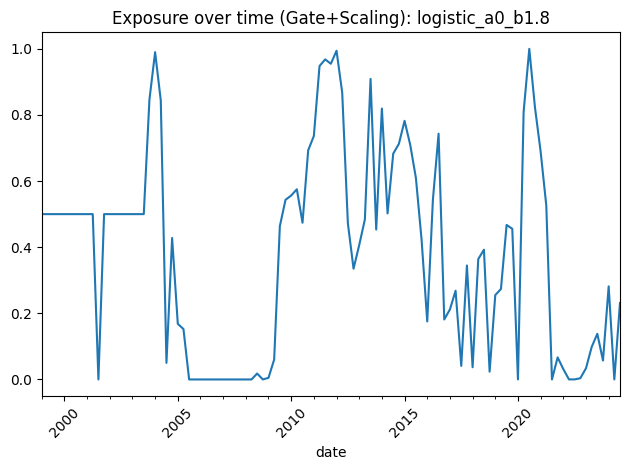

In [3]:
s = pd.Series(df[EXPO_COL].values, index=df["date"])
ax = s.plot(title=f"Exposure over time (Gate+Scaling): {best}")
plt.xticks(rotation=45)
plt.tight_layout()


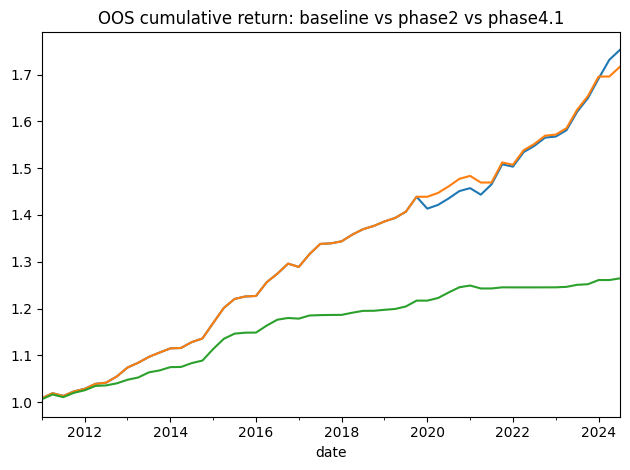

In [4]:
def cumprod_series(r: pd.Series) -> pd.Series:
    r = r.fillna(0)
    return (1 + r).cumprod()

oos = df["is_oos"].astype(bool)

r_base = pd.Series(df.loc[oos, "strat_baseline"].values, index=df.loc[oos, "date"])
ax = cumprod_series(r_base).plot(title="OOS cumulative return: baseline vs phase2 vs phase4.1")
plt.xticks(rotation=45)

if "strat_p2" in df.columns and df["strat_p2"].notna().any():
    r_p2 = pd.Series(df.loc[oos, "strat_p2"].values, index=df.loc[oos, "date"])
    cumprod_series(r_p2).plot(ax=ax)

r_p41 = pd.Series(df.loc[oos, STRAT_COL].values, index=df.loc[oos, "date"])
cumprod_series(r_p41).plot(ax=ax)

plt.tight_layout()


In [5]:
def summarize(r):
    r = pd.Series(r).dropna()
    return pd.Series({
        "n": r.count(),
        "mean": r.mean(),
        "vol": r.std(),
        "p05": np.percentile(r,5),
        "min": r.min(),
    })

tbl = pd.DataFrame({
    "baseline_full": summarize(df.loc[oos, "strat_baseline"]),
    "phase2_gate": summarize(df.loc[oos, "strat_p2"]) if ("strat_p2" in df.columns and df["strat_p2"].notna().any()) else None,
    best: summarize(df.loc[oos, STRAT_COL]),
}).T

display(tbl)


,n,mean,vol,p05,min
baseline_full,55.0,0.010303,0.009649,-0.005537,-0.017667
phase2_gate,55.0,0.009915,0.008974,-0.003971,-0.009567
logistic_a0_b1.8,55.0,0.004289,0.005254,-0.000419,-0.005565
